# 분석예제 2. 중국을 거친 한국 부가가치는 어디로 가는가

본문 `2018_미중무역분쟁과_대미부가가치노출.md`, 산식은 `부록_방법론.md`.

한국에서 창출된 부가가치를 **최종재를 마지막으로 생산한 경제 × 그것을 최종수요로 흡수한 경제**의
두 축으로 분해해 전액을 배분한다. *중국 경유 대미 노출*이 그 격자에서 중국 행, 미국 열에 해당한다.

**필요한 것.** 축소판(`gvc_lite.duckdb`)에는 중간재 거래 행렬 $Z$와 최종수요 $F$가 없어서 이
분석은 돌아가지 않는다. 전체판 `gvc.duckdb`가 있어야 한다.

```
pip install duckdb pandas numpy matplotlib jupyter
```

**소요.** 전부 돌리면 30분 남짓이다. 병목은 행렬 연산이 아니라 DuckDB에서 연도마다 $Z$를 읽는
부분이다(연도당 25초). §3이 13분, §8이 6분, §10이 13분이고 나머지는 즉시다.

## §0. 준비

In [1]:
import os, warnings, time, io, urllib.request
import duckdb, numpy as np, pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 60)

EDITION = 'ICIO2025_EXT'   # 확장판. 중국이 가공무역(CN2)과 가공무역 제외(CN1)로 나뉜다
EDITION_SML = 'ICIO2025'   # 표준판. §10 의 대조용
HOME = 'KOR'

CANDIDATES = ['data/processed/gvc.duckdb', '../data/processed/gvc.duckdb',
              '../../data/processed/gvc.duckdb', '../../../data/processed/gvc.duckdb',
              'gvc.duckdb', '../gvc.duckdb', '../../gvc.duckdb']
DB = next((p for p in CANDIDATES if os.path.exists(p)), None)
if DB is None:
    raise FileNotFoundError('gvc.duckdb 를 찾지 못했다. CANDIDATES 에 경로를 더하거나 파일을 옮긴다.')
con = duckdb.connect(DB, read_only=True)

# 축소판인지 확인한다. 이 분석은 원표가 없으면 아무것도 못 한다.
TABLES = {r[0] for r in con.execute("select table_name from information_schema.tables").fetchall()}
HAS_Z = {'fact_icio_z', 'fact_icio_fd'} <= TABLES
if not HAS_Z:
    raise RuntimeError('축소판 DB 다. 이 분석은 fact_icio_z 와 fact_icio_fd 가 있어야 한다 — '
                       '릴리스에서 gvc.duckdb 를 받을 것.')
print(f'DB: {DB}')

# 그림 라벨은 언제나 영문이다(2026-09-09). 한글 논문과 뒤에 쓸 영문 논문이 같은 그림을 쓰고,
# 한글 글꼴이 없는 환경에서도 그림이 깨지지 않는다. 표는 언제나 한글이다.
KO = False
def L(ko, en):
    return ko if KO else en

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.unicode_minus': False,       # 음수 기호를 U+2212 대신 ASCII 하이픈으로
    'font.size': 11.4,                 # 기본 9.5 에서 20% 키웠다
    'axes.grid': True, 'grid.color': '0.87', 'grid.linewidth': 0.7,
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.dpi': 110, 'savefig.dpi': 500,
})

FIGDIR = 'fig'
def savefig(fig, name):
    try:
        os.makedirs(FIGDIR, exist_ok=True)
        fig.savefig(os.path.join(FIGDIR, name), bbox_inches='tight')
    except Exception as e:
        print('그림 저장 실패:', e)

BN = 1000.0        # 원자료 단위가 백만 달러다. 십억 달러로 보일 때 나눈다
YRS = [1995, 2000, 2005, 2010, 2015, 2017, 2018, 2019, 2020, 2021, 2022]   # 표에 보일 연도
CHECKS = []        # §11 검증이 읽는다
def chk(name, got, want, tol):
    ok = abs(got - want) <= tol
    CHECKS.append((name, got, want, ok))
    return ok

DB: ../../data/processed/gvc.duckdb


## §1. 격자와 산식

$Z$는 중간재 거래, $F$는 최종수요, $X$는 총산출이다. 투입계수 $A = Z\hat{X}^{-1}$, 부가가치 계수
$v = \mathbf{1}' - \mathbf{1}'A$로 두면 $v_j$가 생산물세를 포함한 정의가 된다. 그래야
$v'B = \mathbf{1}'$이 성립해 최종수요가 잔차 없이 분해된다.

한국 산업 $n$의 계수만 남긴 벡터를 $v^{(n)}$이라 하고

$$U_{kn} = \left( v^{(n)\prime} B \right)_k, \qquad M_{n,c,d} = \sum_{k \in c} U_{kn} F_{k,d}$$

$B$를 만들지 않는다. 위 식은 $(I-A)' U = V$로 바꿔 풀 수 있고 우변이 한국 산업 50개뿐이라
LU 한 번에 50개를 함께 푼다. 격자 $4{,}250$에서 $B$를 만드는 것보다 메모리가 3분의 1이다.

In [2]:
def grid(edition):
    ent = con.execute("select code, economy from dim_icio_entity where edition=? order by code",
                      [edition]).df()
    inds = [r[0] for r in con.execute(
        "select icio_ind from dim_icio_ind where edition=? order by ind_no", [edition]).fetchall()]
    return ent['code'].tolist(), ent['economy'].tolist(), inds

def load_year(edition, year, ctys, inds):
    """한 해치를 조밀 행렬로 올린다. 없는 조합은 0 이다."""
    G, N = len(ctys), len(inds)
    GN = G * N
    ci = {(c, i): g * N + n for g, c in enumerate(ctys) for n, i in enumerate(inds)}
    cidx = {c: g for g, c in enumerate(ctys)}

    Z = np.zeros((GN, GN))
    z = con.execute("select src_cty, src_ind, dst_cty, dst_ind, value from fact_icio_z "
                    "where edition=? and year=?", [edition, year]).df()
    Z[[ci[(a, b)] for a, b in zip(z.src_cty, z.src_ind)],
      [ci[(a, b)] for a, b in zip(z.dst_cty, z.dst_ind)]] = z.value.to_numpy()

    F = np.zeros((GN, G))
    f = con.execute("select src_cty, src_ind, dst_cty, sum(value) v from fact_icio_fd "
                    "where edition=? and year=? group by 1,2,3", [edition, year]).df()
    np.add.at(F, ([ci[(a, b)] for a, b in zip(f.src_cty, f.src_ind)],
                  [cidx[c] for c in f.dst_cty]), f.v.to_numpy())

    va = con.execute("select cty, ind, tls, va, out from fact_icio_va where edition=? and year=?",
                     [edition, year]).df()
    X = np.zeros(GN); VA = np.zeros(GN); TLS = np.zeros(GN)
    pos = [ci[(a, b)] for a, b in zip(va.cty, va.ind)]
    X[pos] = va.out.to_numpy(); VA[pos] = va.va.to_numpy(); TLS[pos] = va.tls.to_numpy()
    return Z, F, X, VA, TLS

def coeffs(Z, X):
    safe = np.where(X > 0, X, 1.0)
    A = Z / safe[None, :]
    A[:, X <= 0] = 0.0
    v = 1.0 - A.sum(axis=0)
    v[X <= 0] = 0.0
    return A, v

CTYS, ECON, INDS = grid(EDITION)
G, N = len(CTYS), len(INDS)
GN = G * N
YEARS = [r[0] for r in con.execute(
    "select distinct year from fact_icio_va where edition=? order by year", [EDITION]).fetchall()]
HOME_CELL = np.array([c == HOME for c in CTYS]).repeat(N)
NH = int(HOME_CELL.sum())
USA = CTYS.index('USA')
USA_CELLS = np.repeat(CTYS, N) == 'USA'
ECON_ARR = np.array(ECON)
print(f'격자 {G} x {N} = {GN},  자국 {HOME} 셀 {NH}개,  연도 {YEARS[0]}-{YEARS[-1]} {len(YEARS)}개')

# 산업 한글 이름. 표는 언제나 한글이다.
KO_IND = {
    'A01': '농업·수렵', 'A02': '임업', 'A03': '어업', 'B05': '석탄광업', 'B06': '원유·천연가스',
    'B07': '금속광업', 'B08': '기타 광업', 'B09': '광업 지원서비스', 'C10T12': '식품·음료·담배',
    'C13T15': '섬유·의복·가죽', 'C16': '목재·나무제품', 'C17_18': '종이·인쇄',
    'C19': '코크스·석유정제', 'C20': '화학', 'C21': '의약품', 'C22': '고무·플라스틱',
    'C23': '비금속광물', 'C24A': '1차 철강', 'C24B': '비철금속', 'C25': '금속가공제품',
    'C26': '컴퓨터·전자·광학기기', 'C27': '전기장비', 'C28': '기타 기계·장비',
    'C29': '자동차·트레일러', 'C301': '선박', 'C302T309': '기타 운송장비',
    'C31T33': '가구·기타제조·수리', 'D': '전기·가스', 'E': '수도·폐기물', 'F': '건설',
    'G': '도소매·자동차수리', 'H49': '육상운송', 'H50': '수상운송', 'H51': '항공운송',
    'H52': '운송 창고·지원', 'H53': '우편·배송', 'I': '숙박·음식', 'J58T60': '출판·영상·방송',
    'J61': '통신', 'J62_63': '컴퓨터 프로그래밍·정보서비스', 'K': '금융·보험', 'L': '부동산',
    'M': '전문·과학·기술서비스', 'N': '사업지원서비스', 'O': '공공행정·국방', 'P': '교육',
    'Q': '보건·사회복지', 'R': '예술·여가', 'S': '기타 서비스', 'T': '가구내 고용',
}
def ko(i):
    return f'{i} {KO_IND.get(i, i)}'

격자 85 x 50 = 4250,  자국 KOR 셀 50개,  연도 1995-2022 28개


## §2. 구성의 명제 — 대중 수출 구성 (본문 표 1)

검증 대상인 통념에는 성질이 다른 두 명제가 겹쳐 있다. 하나는 한국의 대중 수출 대부분이 중간재라는
구성의 명제이고, 다른 하나는 그것이 중국에서 조립되어 미국으로 간다는 목적지의 명제다. 구성부터 검증한다. 중간재는
$Z$에서 한국 행·중국 열, 최종재는 $F$에서 한국 행·중국 열이다. 확장판에서 중간재의 도착지는
`CN1`·`CN2`로 갈리지만 최종수요 열은 여전히 `CHN` 하나다.

In [3]:
tab1 = con.execute(f'''
    with z as (select year, sum(value) v from fact_icio_z
               where edition='{EDITION}' and src_cty='{HOME}'
                 and dst_cty in ('CN1','CN2') group by 1),
         f as (select year, sum(value) v from fact_icio_fd
               where edition='{EDITION}' and src_cty='{HOME}'
                 and dst_cty='CHN' group by 1)
    select z.year as 연도, round(z.v/1000,1) as 중간재,
           round(100*z.v/(z.v+f.v),1) as 중간재비중, round(f.v/1000,1) as 최종재,
           round(100*f.v/(z.v+f.v),1) as 최종재비중
    from z join f using(year) order by 1
''').df().set_index('연도')
print('표 1. 한국의 대중 수출 구성 (십억 달러)')
tab1.loc[YRS]

표 1. 한국의 대중 수출 구성 (십억 달러)


,중간재,중간재비중,최종재,최종재비중
연도,,,,
1995,8.3,80.6,2.0,19.4
2000,17.9,82.6,3.8,17.4
2005,50.6,74.6,17.2,25.4
2010,87.5,71.2,35.5,28.8
2015,147.2,81.8,32.8,18.2
2017,152.6,79.1,40.2,20.9
2018,170.6,76.7,51.9,23.3
2019,145.0,78.3,40.1,21.7
2020,136.5,78.5,37.4,21.5


구성의 명제는 성립한다. 중간재 비중은 2010년의 71.2%를 저점으로 대체로 77~82% 사이에 있고 2022년
78.5%다. "80% 이상"이라는 표현이 약간 높지만 자릿수의 문제는 아니다.

## §3. 최종 귀착 분해 (약 13분)

이 절이 나머지 전부의 재료를 만든다. 연도마다 $U$를 풀고 개체 블록마다 $F$를 곱해 두 축으로 접는데,
$M$ 전체를 쌓아 두면 9백만 행이 되므로 필요한 집계만 남긴다. `MUS`는 자국 산업 × 최종재 생산 개체
(흡수지는 미국)이고, `MABS`는 최종재 생산 개체 × 흡수 개체(자국 산업을 합친 것)다.

같은 회전에서 총수출 기준 척도도 함께 낸다. 선행연구가 계산한 *중국의 대미 수출에 체화된 한국 부가가치*과
개념을 맞추기 위한 것으로, 중국이 미국에 파는 것 **전부**(중간재 포함)에 체화된 한국 부가가치다.
$U$를 이미 풀어 두었으므로 추가 비용이 없다.

검산은 $\sum M$이 한국의 $VA + TLS$ 합과 같아야 한다는 것이다. 원표 자체가 $10^{-3}$ 안에서만
균형하므로 그보다 작은 오차면 우리 계산의 결함이 아니다.

In [4]:
MUS  = {}   # year -> (NH x G)  자국 산업 x 최종재 생산 개체, 흡수지 = 미국
MABS = {}   # year -> (G x G)   최종재 생산 개체 x 흡수 개체
gross_rows = []
t_all = time.time()

for year in YEARS:
    t0 = time.time()
    Z, F, X, VA, TLS = load_year(EDITION, year, CTYS, INDS)
    A, v = coeffs(Z, X)

    V = np.zeros((GN, NH))
    V[np.nonzero(HOME_CELL)[0], np.arange(NH)] = v[HOME_CELL]
    U = np.linalg.solve((np.eye(GN) - A).T, V)      # LU 한 번, 우변 50개
    del A

    mus = np.zeros((NH, G))
    mabs = np.zeros((G, G))
    for g in range(G):
        sl = slice(g * N, (g + 1) * N)
        Mc = U[sl].T @ F[sl]                        # NH x G
        mus[:, g] = Mc[:, USA]
        mabs[g, :] = Mc.sum(axis=0)
    MUS[year], MABS[year] = mus, mabs

    # 총수출 기준: 중국이 미국에 파는 것 전부에 담긴 한국 부가가치
    u = U.sum(axis=1)
    to_us = Z[:, USA_CELLS].sum(axis=1) + F[:, USA]
    via = np.repeat(ECON_ARR, N) == 'CHN'
    gross_rows.append(dict(year=year, 총수출=to_us[via].sum(),
                           한국VA_총수출기준=(u * to_us)[via].sum(),
                           한국VA_최종흡수기준=(u * F[:, USA])[via].sum()))
    del Z, F, U

    tgt = (VA + TLS)[HOME_CELL].sum()
    err = abs(mabs.sum() - tgt) / tgt
    print(f'{year}  VA {tgt:12,.0f}  분해합 {mabs.sum():12,.0f}  상대오차 {err:.2e}'
          f'  ({time.time() - t0:.0f}s)', flush=True)

print(f'\n합계 {time.time() - t_all:.0f}초')
TOT = pd.Series({y: MABS[y].sum() for y in YEARS})          # 한국 부가가치 총액
gross = pd.DataFrame(gross_rows).set_index('year')
gross['VA비중'] = 100 * gross.한국VA_총수출기준 / gross.총수출

1995  VA      533,060  분해합      533,048  상대오차 2.32e-05  (21s)


1996  VA      573,726  분해합      573,723  상대오차 4.53e-06  (21s)


1997  VA      535,884  분해합      535,876  상대오차 1.46e-05  (21s)


1998  VA      364,735  분해합      364,711  상대오차 6.44e-05  (21s)


1999  VA      468,009  분해합      467,991  상대오차 3.76e-05  (21s)


...

2019  VA    1,570,136  분해합    1,570,128  상대오차 4.98e-06  (25s)


2020  VA    1,560,565  분해합    1,560,536  상대오차 1.87e-05  (25s)


2021  VA    1,847,927  분해합    1,847,925  상대오차 7.53e-07  (26s)


2022  VA    1,721,252  분해합    1,721,267  상대오차 8.65e-06  (26s)



합계 666초


검산은 28개 연도 모두 통과했고 상대오차의 최댓값이 $2.3 \times 10^{-5}$다. 원표의 균형 한계
$10^{-3}$ 안이므로 계산의 결함이 아니다.

## §4. 목적지의 명제 — 중국의 대미 수출에 체화된 한국 부가가치 (본문 표 2)

목적지의 명제를 검증한다. *총수출 기준*이 선행연구가 계산한 것과 같은 개념이고, *최종흡수 기준*은
그중 미국의 최종수요가 실제로 흡수한 몫이다. 미국이 중국산 중간재로 만들어 다시 수출하는 몫은
앞에는 들어가고 뒤에는 빠지므로 앞이 언제나 크다.

In [5]:
tab2 = pd.DataFrame({
    '중국의 대미 총수출': gross.총수출 / BN,
    '한국VA(총수출기준)': gross.한국VA_총수출기준 / BN,
    'VA비중%': gross.VA비중,
    '한국VA(최종흡수기준)': gross.한국VA_최종흡수기준 / BN,
})
print('표 2. 중국의 대미 수출에 담긴 한국 부가가치 (십억 달러, %)')
tab2.loc[[2004, 2010, 2015, 2017, 2018, 2019, 2020, 2021, 2022]].round(2)

표 2. 중국의 대미 수출에 담긴 한국 부가가치 (십억 달러, %)


,중국의 대미 총수출,한국VA(총수출기준),VA비중%,한국VA(최종흡수기준)
year,,,,
2004,150.52,4.27,2.84,2.92
2010,278.86,5.23,1.87,3.68
2015,427.56,8.20,1.92,6.14
2017,427.71,8.90,2.08,6.40
2018,473.62,9.72,2.05,6.79
2019,418.23,7.06,1.69,4.75
2020,418.93,6.45,1.54,4.35
2021,519.91,8.53,1.64,5.72
2022,532.15,6.78,1.27,4.55


목적지의 명제는 정점에서도 작았다. 중국이 미국에 파는 것에서 한국 몫은 2004년 2.84%가 정점이었고 2018년 2.05%,
2022년 1.27%다. 28개 연도를 통틀어 3%를 넘은 해가 없다. 2022년 중국의 대미 총수출은 2018년보다 오히려 12% 크지만 그 안의 한국 부가가치는 97.2억에서
67.8억 달러로 30% 줄었다. 중국이 미국에 파는 양이 아니라 그 안의 한국 부가가치 비중이 줄어든 것이다. 최종흡수 기준은 총수출 기준의 67~75%이며, 나머지는 중국이 미국에 수출한 중간재에 체화되어 미국 안에서 최종재가 된다.

## §5. 미국 최종수요에 대한 경로별 노출 (본문 표 3·그림 1)

대상을 바꾸어 미국의 최종수요가 흡수한 한국 부가가치 전체를 놓고 어느 경로로 도달했는지를 구분한다.
`KOR`은 한국이 만든 최종재를 미국이 사는 직접 경로이고, `USA`는 한국 중간재가 미국 안의 생산에
투입되어 미국의 최종재가 되는 경로이며, 나머지는 제3국이 최종재를 만든 경로다.

In [6]:
KEY = ['KOR', 'USA', 'CHN', 'VNM', 'MEX']
fold = pd.Series(ECON_ARR).where(pd.Series(ECON_ARR).isin(KEY), '기타')
route = pd.DataFrame({y: pd.Series(MUS[y].sum(axis=0)).groupby(fold).sum() for y in YEARS}).T
route = route[KEY + ['기타']]
route['합계'] = route.sum(axis=1)
tab3 = route / BN
share = route[KEY + ['기타']].div(route['합계'], axis=0) * 100
print('표 3. 미국 최종수요가 흡수한 한국 부가가치의 최종재 생산지별 구성 (십억 달러)')
display(tab3.loc[YRS].round(1))
print('\n구성비 (%)')
share.loc[YRS].round(1)

표 3. 미국 최종수요가 흡수한 한국 부가가치, 최종재 생산지별 (십억 달러)


,KOR,USA,CHN,VNM,MEX,기타,합계
1995,13.9,7.7,0.3,0.0,0.2,2.0,24.1
2000,23.6,11.4,0.9,0.0,0.8,3.1,39.8
2005,21.8,17.0,3.5,0.2,1.2,3.7,47.4
2010,21.3,17.6,3.7,0.3,2.1,3.7,48.7
2015,35.8,24.7,6.1,1.3,2.8,4.8,75.5
2017,36.1,24.6,6.4,2.4,3.5,5.2,78.3
2018,35.5,25.0,6.8,2.4,3.7,5.5,79.0
2019,35.9,25.7,4.8,2.8,3.4,5.0,77.4
2020,36.5,25.2,4.3,3.2,2.9,4.8,76.9
2021,42.5,33.2,5.7,4.1,3.5,6.0,95.0



구성비 (%)


,KOR,USA,CHN,VNM,MEX,기타
1995,57.5,31.9,1.4,0.0,1.0,8.1
2000,59.2,28.6,2.3,0.0,2.0,7.8
2005,46.0,35.8,7.4,0.3,2.6,7.9
2010,43.8,36.1,7.6,0.7,4.3,7.6
2015,47.4,32.7,8.1,1.8,3.7,6.3
2017,46.2,31.5,8.2,3.1,4.5,6.6
2018,44.9,31.7,8.6,3.1,4.7,7.0
2019,46.3,33.1,6.1,3.7,4.3,6.4
2020,47.4,32.8,5.7,4.1,3.8,6.2
2021,44.8,34.9,6.0,4.3,3.7,6.3


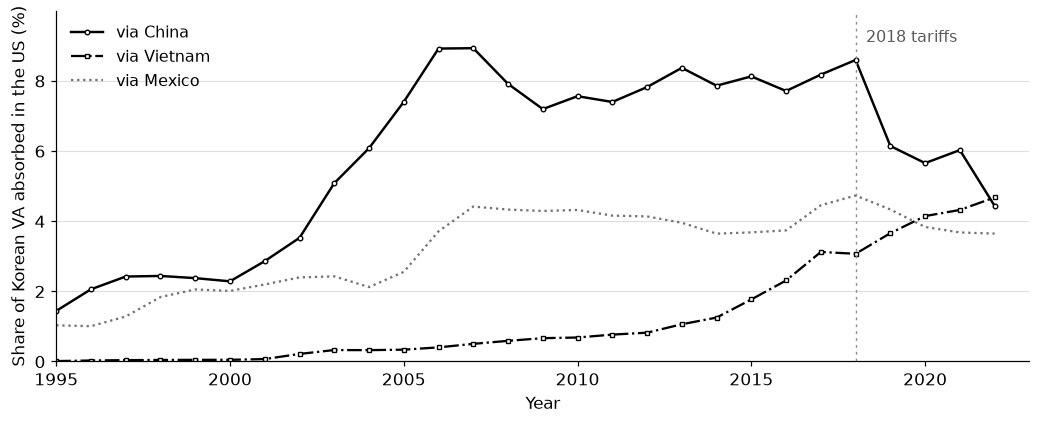

In [7]:
# 그림 1. 한국 직접(45%)·미국 내 생산(36%)은 축을 눌러 정작 볼 것을 가리므로 표에 두고,
# 여기서는 경유 경로 셋만 그린다. 표로는 두 계열이 교차하는 시점이 드러나지 않는다.
fig, ax = plt.subplots(figsize=(9.6, 4.0))
style = {'CHN': ('-', '0.0', 1.6, 'o'), 'VNM': ('-.', '0.0', 1.5, 's'),
         'MEX': (':', '0.45', 1.5, None)}
name = {'CHN': L('중국 경유', 'via China'), 'VNM': L('베트남 경유', 'via Vietnam'),
        'MEX': L('멕시코 경유', 'via Mexico')}
for k, (ls, c, lw, mk) in style.items():
    ax.plot(share.index, share[k].values, ls, color=c, linewidth=lw, label=name[k],
            marker=mk, markersize=3.0, markerfacecolor='white', markeredgewidth=0.9)
ax.xaxis.grid(False)   # 세로 그리드는 끈다(연구 1과 같다)
ax.axvline(2018, color='0.55', linewidth=0.9, linestyle=(0, (2, 3)))
top = share[['CHN', 'VNM', 'MEX']].max().max()
ax.annotate(L('2018년 관세', '2018 tariffs'), xy=(2018.3, top * 1.02), fontsize=10.2, color='0.35')
ax.set_xlabel(L('연도', 'Year'))
ax.set_ylabel(L('미국 최종수요에 체화된 한국 부가가치 중 비중 (%)',
                'Share of Korean VA absorbed in the US (%)'))
ax.set_xlim(YEARS[0], YEARS[-1] + 1)
ax.set_ylim(0, top * 1.12)
ax.legend(frameon=False, fontsize=10.6, loc='upper left')
fig.tight_layout()
savefig(fig, 'fig1_route.png')
plt.show()

중국 경유는 2006~2007년에 이미 8.9%로 정점을 찍고 이후 11년 동안 7~9% 사이에서 평평했으며 2018년의
8.6%가 그 구간의 마지막이다. 2019년의 낙하는 그 이전 어느 해의 변동과도 크기가 다르다. 관세 이전에
이미 정점이 지나 있었으므로 낙하를 관세 하나로 돌릴 수는 없다. 같은 기간 전체 노출은 790억
달러에서 1,026억 달러로 오히려 커졌으므로, 줄어든 것은 노출 자체가 아니라 중국을 지나는 경로다.

## §6. 중국 경유의 내부 — 가공무역과 중국 내수 (본문 표 4)

중국을 거친 한국 부가가치 전체를 놓고 그 내부를 구분한다. 최종재를 만든 부문이 가공무역(`CN2`)인지 그
밖(`CN1`)인지가 한 축이고, 그것을 흡수한 곳이 다른 축이다. 가공무역 부문의 산출은 정의상 수출되므로
중국 내수 칸이 없다.

In [8]:
def absorb_group(code):
    return {'CHN': '중국내수', 'USA': '미국'}.get(code, '제3국')

grp = pd.Series([absorb_group(c) for c in CTYS])
rows = {}
for y in YEARS:
    d = pd.DataFrame(MABS[y], index=CTYS, columns=CTYS)
    for ent in ['CN1', 'CN2']:
        s = d.loc[ent].groupby(grp.values).sum()
        for g2, val in s.items():
            rows.setdefault((ent, g2), {})[y] = val
tab4 = pd.DataFrame(rows) / BN
tab4 = tab4.reindex(columns=[('CN1', '중국내수'), ('CN1', '미국'), ('CN1', '제3국'),
                             ('CN2', '미국'), ('CN2', '제3국')])
tab4['합계'] = tab4.sum(axis=1)
tab4['총VA대비%'] = tab4['합계'] * BN / TOT * 100
print('표 4. 중국산 최종재에 체화된 한국 부가가치의 부문별·흡수지별 구성 (십억 달러)')
tab4.loc[YRS].round(2)

표 4. 중국이 최종재를 만든 한국 부가가치 (십억 달러). CN1 = 가공무역 제외, CN2 = 가공무역


CN1               CN2             합계 총VA대비%
       중국내수    미국   제3국    미국    제3국               
1995   4.70  0.12  0.32  0.23   0.37    5.74   1.08
2000   9.14  0.28  0.57  0.63   0.80   11.42   2.11
2005  20.30  0.84  1.70  2.67   4.12   29.62   3.36
2010  35.01  0.85  2.50  2.83   7.41   48.60   4.47
2015  70.73  1.60  4.79  4.54  11.06   92.72   6.65
2017  73.95  1.72  5.08  4.68  11.91   97.33   6.31
2018  83.85  1.83  5.41  4.96  12.02  108.07   6.59
2019  71.73  1.17  4.13  3.58  11.17   91.79   5.85
2020  70.08  1.26  4.57  3.09  10.03   89.02   5.70
2021  85.61  1.65  6.20  4.07  13.68  111.21   6.02
2022  71.38  1.32  5.14  3.22  12.09   93.15   5.41

표는 통념이 놓친 것을 보인다. 2022년 중국산 최종재에 체화된 한국 부가가치 931.5억 달러 가운데
중국 자신이 소비한 것이 713.8억으로 76.6%이고 미국행은 45.5억으로 4.9%에 지나지 않는다. 한국의
중간재가 중국으로 가는 것은 맞지만 그 대부분은 미국으로 나가지 않고 중국 안에 머문다. 한국이 중국에
갖는 노출의 실체는 우회가 아니라 중국 내수인 것이다. 대미 경로 안에서는 가공무역이 더 크게 줄어,
`CN2`를 거친 대미분이 4.96에서 3.22로 35% 감소해 `CN1`의 28% 감소보다 크다.

## §7. 산업별과 대체 가설 (본문 표 5·그림 2)

집계에서 중국 경유가 줄고 베트남 경유가 늘었다는 것만으로는 경로가 옮겨갔다고 말할 수 없다. 두 변화가
우연히 크기만 맞은 것일 수 있기 때문이다. 옮겨간 것이라면 중국에서 줄어든 산업과 베트남에서 늘어난
산업이 같아야 한다. 부가가치가 발생한 한국 산업별로 두 경로의 2018년과 2022년 값을 놓는다.

In [9]:
def by_ind(year, econ):
    sel = ECON_ARR == econ
    return pd.Series(MUS[year][:, sel].sum(axis=1), index=INDS)

ind = pd.DataFrame({'중국2018': by_ind(2018, 'CHN'), '중국2022': by_ind(2022, 'CHN'),
                    '베트남2018': by_ind(2018, 'VNM'), '베트남2022': by_ind(2022, 'VNM')})
ind['중국변화'] = ind['중국2022'] - ind['중국2018']
ind['베트남변화'] = ind['베트남2022'] - ind['베트남2018']
ind['규모'] = pd.Series(MUS[2018].sum(axis=1), index=INDS)     # 그 산업의 2018년 대미 노출 전체
ind.index = [ko(i) for i in ind.index]
print('표 5. 산업별 중국 경유 대미 노출 상위 10 (백만 달러)')
ind.sort_values('중국2018', ascending=False).head(10)[
    ['중국2018', '중국2022', '베트남2018', '베트남2022', '중국변화', '베트남변화']].round(0)

표 5. 산업별 중국 경유 대미 노출 상위 10 (백만 달러)


,중국2018,중국2022,베트남2018,베트남2022,중국변화,베트남변화
C26 컴퓨터·전자·광학기기,3100.0,2044.0,788.0,1969.0,-1056.0,1181.0
G 도소매·자동차수리,901.0,599.0,347.0,664.0,-302.0,317.0
C20 화학,436.0,286.0,171.0,268.0,-151.0,97.0
M 전문·과학·기술서비스,253.0,145.0,96.0,140.0,-108.0,44.0
N 사업지원서비스,171.0,118.0,51.0,94.0,-53.0,43.0
K 금융·보험,152.0,109.0,61.0,117.0,-44.0,56.0
C27 전기장비,134.0,106.0,55.0,119.0,-28.0,64.0
C22 고무·플라스틱,127.0,83.0,96.0,125.0,-44.0,30.0
C28 기타 기계·장비,121.0,63.0,42.0,62.0,-59.0,20.0
H52 운송 창고·지원,106.0,62.0,33.0,53.0,-44.0,19.0


In [10]:
keep = (ind['중국2018'] > 10) | (ind['베트남2022'] > 10)      # 규모 있는 산업만
k = ind[keep]
x, y = k['중국변화'], k['베트남변화']
C26 = ko('C26')

def line(lab, xx, yy):
    print(f'  {lab:12s} n={len(xx):2d}  피어슨 {np.corrcoef(xx, yy)[0,1]:+.3f}  '
          f'스피어만 {xx.rank().corr(yy.rank()):+.3f}  기울기 {np.polyfit(xx, yy, 1)[0]:+.3f}')

print(f'대체 가설 검정 — 금액 그대로 (대상 {int(keep.sum())}개 산업)')
line('전체', x, y)
line('C26 제외', x.drop(C26), y.drop(C26))
print(f'  합계   중국 {x.sum():+,.0f}  베트남 {y.sum():+,.0f} (백만 달러)')
print(f'  C26 몫 중국 감소분의 {100*x[C26]/x.sum():.0f}%, 베트남 증가분의 {100*y[C26]/y.sum():.0f}%')

xn, yn = x / k['규모'] * 100, y / k['규모'] * 100              # 산업 규모를 걷어낸다
print('\n같은 것을 산업 규모로 나눈 뒤')
line('전체', xn, yn)
line('C26 제외', xn.drop(C26), yn.drop(C26))

대체 가설 검정 — 금액 그대로 (대상 36개 산업)
  전체           n=36  피어슨 -0.987  스피어만 -0.398  기울기 -1.094
  C26 제외       n=35  피어슨 -0.858  스피어만 -0.345  기울기 -0.824
  합계   중국 -2,221  베트남 +2,356 (백만 달러)
  C26 몫 중국 감소분의 48%, 베트남 증가분의 50%

같은 것을 산업 규모로 나눈 뒤
  전체           n=36  피어슨 +0.305  스피어만 +0.425  기울기 +0.340
  C26 제외       n=35  피어슨 +0.531  스피어만 +0.542  기울기 +0.596


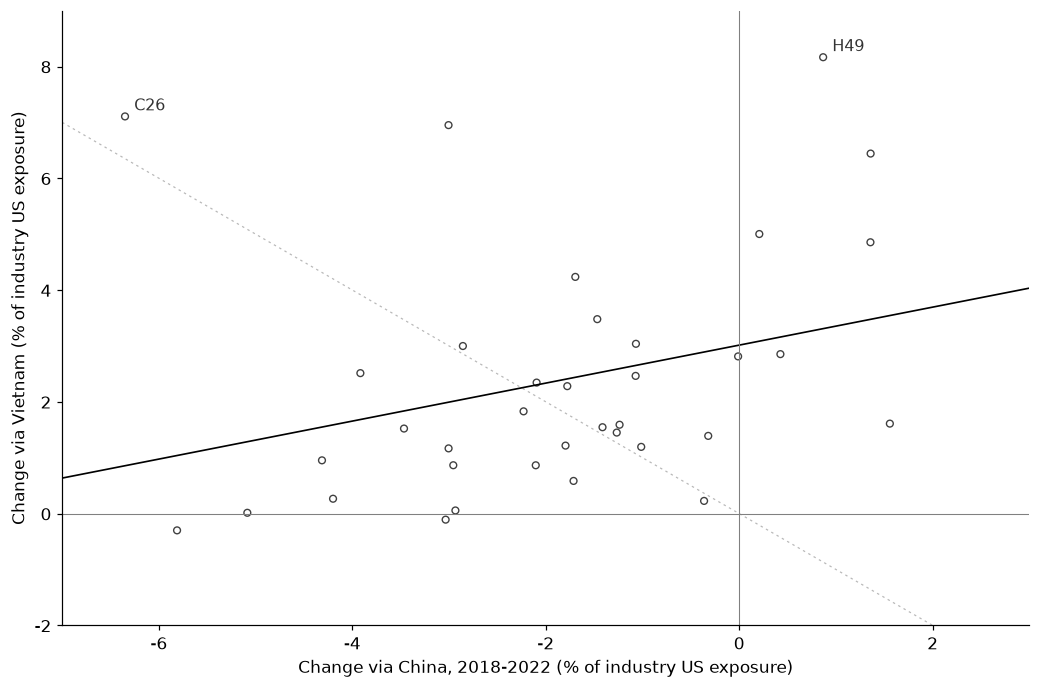

In [11]:
# 그림 2. 금액 그대로 그리면 C26 하나가 화면을 차지하고 나머지 35개가 원점에 뭉쳐 아무것도
# 보이지 않는다. 산업 규모로 나눈 상대 변화로 그린다. 대체가 산업마다 일어났다면 우하향해야 한다.
import matplotlib.patheffects as pe
HALO = [pe.withStroke(linewidth=3.0, foreground='white')]   # 선 위에 얹힌 글자를 읽히게 한다

fig, ax = plt.subplots(figsize=(9.6, 6.4))
ax.scatter(xn, yn, s=20, facecolors='none', edgecolors='0.25', linewidths=0.9)
ax.grid(False)
lo, hi = -7.0, 3.0     # 가로축. C26 이 -6.35 라 -6 으로 끊으면 잘린다
ylo, yhi = -2.0, 9.0   # 세로축
ax.plot([lo, hi], [-lo, -hi], color='0.55', linewidth=1.4, linestyle=(0, (3, 3)))
b, a = np.polyfit(xn, yn, 1)
ax.plot([lo, hi], [a + b * lo, a + b * hi], color='0.0', linewidth=1.4)
ax.axhline(0, color='0.75', linewidth=0.7)
ax.axvline(0, color='0.75', linewidth=0.7)
for nm in dict.fromkeys(list(xn.sort_values().index[:1]) + list(yn.sort_values().index[-1:])):
    ax.annotate(nm.split(' ', 1)[1] if KO else nm.split(' ', 1)[0], (xn[nm], yn[nm]),
                fontsize=11.5, xytext=(7, 5), textcoords='offset points', color='0.0',
                path_effects=HALO)
ax.set_xlim(lo, hi); ax.set_ylim(ylo, yhi)
ax.set_xlabel(L('중국 경유 노출 변화, 2018→2022 (산업 대미 노출 대비 %p)',
                'Change via China, 2018-2022 (% of industry US exposure)'))
ax.set_ylabel(L('베트남 경유 노출 변화 (산업 대미 노출 대비 %p)',
                'Change via Vietnam (% of industry US exposure)'))

# 범례 대신 선 위에 이름표를 얹는다. 각도는 최종 배치가 정해진 뒤에 계산해야 선과 어긋나지 않는다
fig.tight_layout()
fig.canvas.draw()
def slope_deg(m):
    p = ax.transData.transform([[0, 0], [1, m]])
    return np.degrees(np.arctan2(p[1, 1] - p[0, 1], p[1, 0] - p[0, 0]))
ax.text(-4.9, 5.2, L('기울기 -1 (완전 대체)', 'slope -1 (full substitution)'),
        rotation=slope_deg(-1), rotation_mode='anchor', color='0.30', fontsize=11.5,
        ha='left', va='bottom', path_effects=HALO)
ax.text(0.6, a + b * 0.6, L('적합선', 'fitted line'),
        rotation=slope_deg(b), rotation_mode='anchor', color='0.0', fontsize=11.5,
        ha='left', va='bottom', path_effects=HALO)
savefig(fig, 'fig2_substitution.png')
plt.show()


한 산업이 이야기를 지배한다. 컴퓨터·전자·광학기기에서 중국 경유가 10.6억 달러 줄고 베트남 경유가
11.8억 달러 늘어 산업 하나 안에서 거의 정확히 상쇄되며, 이 산업이 전체 중국 감소분의 48%와 베트남
증가분의 50%를 만든다. 금액 그대로의 상관은 -0.987이고 이 산업을 빼도 -0.858로 유지된다.

그러나 금액 상관은 산업의 크기를 반영한다. 큰 산업은 두 방향 모두에서 크게 움직이므로 상관이 높게
나오는 것이 당연하다. 각 산업의 2018년 대미 노출 전체로 나누면 상관이 +0.305로 부호가 뒤집히고
C26을 빼면 +0.531이 된다. 양의 부호는 중국 경유가 상대적으로 더 줄어든 산업에서 베트남 경유가 오히려
덜 늘었다는 뜻이므로 산업마다 경로를 갈아탔다는 해석과 맞지 않는다. 따라서 결론을 좁혀야 한다.
집계 수준의 상쇄는 실재하고 그 절반은 전자산업 하나가 만들며 그 안에서는 대체가 뚜렷하지만, 경제
전반에서 일률적으로 일어난 경로 이전은 아니다.

## §8. 한국은 공통 추세를 벗어났나 (본문 표 6, 약 6분)

중국 경유 경로의 축소가 한국에만 일어난 일인지 중국에 중간재를 대는 모든 나라에 공통인지를 구분한다.
공급 측을 전부 열어야 하므로 여기서는 $B$를 실제로 만든다 — 우변이 경제권 수만큼이라 LU 로 아끼는
이득이 없다.

$$P_{si,c} = \sum_{k \in c} v_{si} B_{si,k} F_{k,\text{USA}}$$

처치의 성질이 연구 1과 다르다는 점을 적어 둔다. 미국의 관세는 중국에 중간재를 대는 **모든** 공급국에
부과 효과가 미치므로 "한국 대 타국"은 인과 추정이 아니라 한국의 축소가 공통 추세를 벗어난 정도를 확인하는 비교다.

In [12]:
PANEL_YEARS = [y for y in YEARS if y >= 2010]
ROUTES = ['CHN', 'VNM', 'MEX', 'USA', 'KOR', 'TWN', 'JPN', 'DEU']
CELL_CTY, CELL_ECON, CELL_IND = np.repeat(CTYS, N), np.repeat(ECON_ARR, N), np.tile(INDS, G)
rows = []
t_all = time.time()

for year in PANEL_YEARS:
    t0 = time.time()
    Z, F, X, VA, TLS = load_year(EDITION, year, CTYS, INDS)
    A, v = coeffs(Z, X)
    del Z
    B = np.linalg.inv(np.eye(GN) - A)
    del A
    w = F[:, USA]
    cols = ROUTES + ['ALL']
    W = np.zeros((GN, len(cols)))
    for j, c in enumerate(ROUTES):
        W[:, j] = np.where(CELL_ECON == c, w, 0.0)
    W[:, -1] = w
    P = (v[:, None] * B) @ W
    del B, F
    nz = np.nonzero(P)
    rows.append(pd.DataFrame({'year': year, 'econ': CELL_ECON[nz[0]], 'ind': CELL_IND[nz[0]],
                              'route': np.array(cols)[nz[1]], 'va': P[nz]}))
    print(f'{year}  ({time.time() - t0:.0f}s)', flush=True)

panel = pd.concat(rows, ignore_index=True)
print(f'\n합계 {time.time() - t_all:.0f}초,  {len(panel):,}행')

2010  (26s)


2011  (26s)


2012  (26s)


2013  (26s)


2014  (26s)


...

2019  (26s)


2020  (26s)


2021  (27s)


2022  (27s)



합계 336초,  463,869행


In [13]:
via_chn = panel[(panel.route == 'CHN') & (~panel.econ.isin(['ROW', 'CHN']))]
sup = via_chn.groupby(['econ', 'year']).va.sum().unstack() / BN
sup['18→22%'] = (sup[2022] / sup[2018] - 1) * 100
cols6 = [c for c in [2010, 2015, 2017, 2018, 2019, 2022] if c in sup.columns] + ['18→22%']
tab6 = sup.sort_values(2018, ascending=False).head(12)[cols6]
print('표 6. 공급 경제별 중국 경유 대미 부가가치 (십억 달러)')
display(tab6.round(2))

d = (sup[2022] / sup[2018] - 1).dropna() * 100
kr = d['KOR']
print(f'\n한국 {kr:+.1f}%  |  {len(d)}개 경제 중위 {d.median():+.1f}%,  '
      f'한국보다 더 줄어든 곳 {(d < kr).sum()}개')

w = via_chn[via_chn.year.isin([2018, 2022])].pivot_table(index=['econ', 'ind'], columns='year',
                                                         values='va').dropna()
w = w[w[2018] > 10]
w['chg'] = (w[2022] / w[2018] - 1) * 100
print(f"산업별 중위 변화율 — 한국 {w.xs('KOR', level='econ')['chg'].median():+.1f}%,  "
      f"타국 {w.drop('KOR', level='econ')['chg'].median():+.1f}%")

표 6. 공급 경제별 중국 경유 대미 부가가치 (십억 달러)


year,2010,2015,2017,2018,2019,2022,18→22%
econ,,,,,,,
KOR,3.68,6.14,6.40,6.79,4.75,4.55,-33.01
JPN,4.94,4.80,5.13,5.33,4.55,4.16,-21.85
USA,3.50,5.44,5.01,5.15,4.06,4.90,-4.73
TWN,3.37,5.12,5.07,4.79,4.19,5.25,9.59
DEU,1.51,2.40,2.40,2.62,2.31,2.37,-9.43
AUS,1.33,1.64,2.14,2.41,2.24,2.74,13.70
RUS,0.73,1.00,1.06,1.50,1.10,1.93,28.60
SAU,1.07,0.89,0.94,1.45,1.05,1.75,21.13
SGP,0.81,1.22,1.38,1.44,1.44,1.76,21.95



한국 -33.0%  |  79개 경제 중위 +5.4%,  한국보다 더 줄어든 곳 1개
산업별 중위 변화율 — 한국 -31.2%,  타국 -5.8%


한국의 감소는 극단이다. 79개 공급 경제의 변화율 중위값이 +5.4%인 동안 한국은 -33.0%이며 한국보다 더
크게 줄어든 경제는 하나뿐이다. 일본이 -21.9%, 독일 -9.4%, 미국 -4.7%인 데 반해 대만은 +9.6%로 늘었다.
같은 시기 중국의 대미 총수출이 12% 늘었음을 감안하면 중국의 대미 공급망에서 한국의 자리만 빠르게
비워졌다는 뜻이 된다. 다만 이 표는 왜 그런지를 말해 주지 않는다 — 관세, 중국의 국산화, 한국 기업의
생산기지 이전이 모두 후보이며 이 자료로는 분리되지 않는다.

## §9. 관세를 처치로 삼는 설계 (본문 표 8·9·10)

관세의 인과효과를 분리하려면 산업 간 처치강도의 차이가 필요하다. 시도했고 식별되지 않았다. 결과를
보고하고 그 이유가 자료 자체에 있음을 관세 자료로 보인다.

노출도는 2017년 중국 산업의 산출 중 대미 수출이 차지하는 비중으로 둔다. 관세 대상 품목의 HS 세번
목록이 이 저장소에 없으므로(품목 층위는 자매 프로젝트가 갖는다) **실제 관세 부과 여부의 대용이며
그것과 같지 않다.** 사양은

$$\log(1 + M_{sit}) = \alpha_{si} + \delta_{st} + \beta\left(\text{post}_t \times \text{exposure}_i\right) + \varepsilon_{sit}$$

고정효과는 더미로 세우지 않고 교대 사영으로 흡수한다. 공급국×산업이 3,800여개라 더미로 넣으면 모수가
군집 수(산업 49개)를 넘어 군집 분산행렬이 특이해진다. $\text{post} \times \mathbf{1}\{s=\text{KOR}\}$
항은 $\delta_{st}$가 이미 흡수하므로 사양에서 뺀다.

In [14]:
exp_df = con.execute(f'''
    with x as (select ind, sum(out) o from fact_icio_va
               where edition='{EDITION}' and year=2017 and cty in ('CN1','CN2') group by 1),
         zi as (select src_ind ind, sum(value) v from fact_icio_z
                where edition='{EDITION}' and year=2017 and src_cty in ('CN1','CN2')
                  and dst_cty='USA' group by 1),
         fi as (select src_ind ind, sum(value) v from fact_icio_fd
                where edition='{EDITION}' and year=2017 and src_cty in ('CN1','CN2')
                  and dst_cty='USA' group by 1)
    select x.ind, x.o, coalesce(zi.v,0)+coalesce(fi.v,0) as to_us
    from x left join zi using(ind) left join fi using(ind)
''').df()
EXPOSURE = (exp_df.to_us / exp_df.o.where(exp_df.o > 0)).fillna(0.0)
EXPOSURE.index = exp_df.ind
print('노출도 상위 6 (2017년 중국 산출 중 대미 수출 비중)')
for i, val in EXPOSURE.sort_values(ascending=False).head(6).items():
    print(f'   {ko(i):28s} {100*val:5.2f}%')

reg = via_chn[via_chn.va > 0].groupby(['year', 'econ', 'ind'], as_index=False).va.sum()
reg['y'] = np.log1p(reg.va)
reg['exposure'] = reg.ind.map(EXPOSURE).fillna(0.0)
reg['si'] = reg.econ + '_' + reg.ind
reg['st'] = reg.econ + '_' + reg.year.astype(str)
reg['kor'] = (reg.econ == 'KOR').astype(float)
reg['pe'] = (reg.year >= 2019).astype(float) * reg.exposure
reg['pek'] = reg.pe * reg.kor
print(f'\n패널 {reg.year.min()}-{reg.year.max()}, 공급 경제 {reg.econ.nunique()}개, '
      f'산업 {reg.ind.nunique()}개, 관측 {len(reg):,}개')

def fe_ols(frame, yv, xv, cluster, keys=('si', 'st'), n_iter=60, tol=1e-10):
    z = frame[[yv] + xv].astype(float).copy()
    for _ in range(n_iter):
        prev = z.to_numpy().copy()
        for kk in keys:
            z = z - z.groupby(frame[kk].to_numpy()).transform('mean')
        if np.max(np.abs(z.to_numpy() - prev)) < tol:
            break
    Xm, yy = z[xv].to_numpy(), z[yv].to_numpy()
    beta = np.linalg.lstsq(Xm, yy, rcond=None)[0]
    e = yy - Xm @ beta
    inv = np.linalg.pinv(Xm.T @ Xm)
    meat = np.zeros((Xm.shape[1], Xm.shape[1]))
    for _, idx in pd.Series(range(len(e))).groupby(np.asarray(cluster)):
        s = Xm[idx.to_numpy()].T @ e[idx.to_numpy()]
        meat += np.outer(s, s)
    Gc = len(np.unique(cluster))
    V = inv @ meat @ inv * (Gc / max(Gc - 1, 1))
    return beta, np.sqrt(np.diag(V)), Gc

B1, S1, GC = fe_ols(reg, 'y', ['pe'], reg.ind.to_numpy())        # 표 8 패널 A (1)
print(f'\n[1] post x 노출도 = {B1[0]:+.4f} (se {S1[0]:.4f}, t {B1[0]/S1[0]:+.2f}, 군집 {GC}개)')
B2, S2, _ = fe_ols(reg, 'y', ['pe', 'pek'], reg.ind.to_numpy())  # 표 8 패널 A (2)
print(f'[2] post x 노출도       = {B2[0]:+.4f} (se {S2[0]:.4f}, t {B2[0]/S2[0]:+.2f})')
print(f'    post x 노출도 x 한국 = {B2[1]:+.4f} (se {S2[1]:.4f}, t {B2[1]/S2[1]:+.2f})')

ev = reg[reg.year >= 2012].copy()
cols = []
for yv in sorted(ev.year.unique()):
    if yv == 2017:
        continue
    ev[f'e{yv}'] = (ev.year == yv).astype(float) * ev.exposure
    cols.append(f'e{yv}')
BE, SE_, _ = fe_ols(ev, 'y', cols, ev.ind.to_numpy())            # 표 8 패널 B
EV = {int(c[1:]): (BE[k], SE_[k]) for k, c in enumerate(cols)}
print('\n[3] 이벤트 스터디 (기준 2017년)')
for yv in sorted(ev.year.unique()):
    if yv == 2017:
        print(f'   {yv}     0.0000   (기준)')
    else:
        print(f'   {yv}  {EV[yv][0]:+9.4f}   {EV[yv][1]:.4f}')

노출도 상위 6 (2017년 중국 산출 중 대미 수출 비중)
   C31T33 가구·기타제조·수리            12.83%
   C26 컴퓨터·전자·광학기기               7.57%
   C13T15 섬유·의복·가죽               4.92%
   C27 전기장비                      4.34%
   C22 고무·플라스틱                   2.83%
   C28 기타 기계·장비                  2.35%

패널 2010-2022, 공급 경제 79개, 산업 49개, 관측 49,733개

[1] post x 노출도 = +0.3961 (se 0.2482, t +1.60, 군집 49개)


[2] post x 노출도       = +0.4232 (se 0.2418, t +1.75)
    post x 노출도 x 한국 = -2.1347 (se 1.1055, t -1.93)

[3] 이벤트 스터디 (기준 2017년)
   2012    -0.6908   0.2850
   2013    +0.0906   0.2650
   2014    +0.6022   0.2550
   2015    +0.0909   0.1442
   2016    +0.4091   0.1733
   2017     0.0000   (기준)
   2018    -0.1194   0.1422
   2019    +0.4586   0.1506
   2020    +0.2532   0.1953
   2021    +0.4904   0.3307
   2022    -0.0399   0.4841


In [15]:
# 실패의 이유는 관세 자료에서 확인된다. 원자료는 저장소에 담지 않고 여기서 받는다
# (제공기관 자료를 재배포하지 않는다 — NOTICE.md). 인터넷이 필요한 유일한 셀이다.
URL = ('https://raw.githubusercontent.com/mwaugh0328/tradewar-tracker/'
       'master/data/us_tariffs_2020.csv')
with urllib.request.urlopen(URL, timeout=120) as r:
    tar = pd.read_csv(io.StringIO(r.read().decode('utf-8')), dtype={'hs6': str})
p = tar.pivot_table(index='hs6', columns='time_of_tariff', values='tariff')
base = p['2018-01-01']
rows = []
for t in ['2018-07-06', '2018-08-23', '2018-09-24', '2019-06-01', '2019-09-01']:
    inc = p[t] - base
    hit = inc > 0.01
    rows.append({'시점': t, '인상 HS6': int(hit.sum()), '비율%': 100 * hit.mean(),
                 '평균 인상폭pp': inc.mean(), '인상분 중위pp': inc[hit].median()})
tab7 = pd.DataFrame(rows).set_index('시점')
print(f'표 10. 미국의 대중 관세 인상 커버리지 (HS6 {len(p):,}개 기준)')
display(tab7.round(2))

ch = (p['2019-09-01'] - base).groupby(p.index.str[:2]).mean().sort_values()
print('낮은 쪽: ' + ', '.join(f'{k}류 {v:.1f}pp' for k, v in ch.head(5).items()))
print('한국 주력 산업이 속한 류: ' + ', '.join(
    f'{c}류 {ch[c]:.1f}pp' for c in ['84', '85', '90'] if c in ch.index))

표 7. 미국의 대중 관세 인상 커버리지 (HS6 5,114개 기준)


,인상 HS6,비율%,평균 인상폭pp,인상분 중위pp
시점,,,,
2018-07-06,557,10.89,2.83,25.0
2018-08-23,721,14.10,3.69,25.0
2018-09-24,3669,71.74,9.54,10.0
2019-06-01,3670,71.76,18.38,25.0
2019-09-01,4955,96.89,22.15,25.0


낮은 쪽: 66장 4.1pp, 95장 11.4pp, 63장 11.4pp, 64장 12.3pp, 67장 12.5pp
한국이 걸린 장: 84장 23.1pp, 85장 24.5pp, 90장 26.7pp


추정된 `post × 노출도` 계수는 +0.396(표준오차 0.248)으로 부호가 예상과 반대이고 통계적으로 구분되지
않는다. 이벤트 스터디는 더 분명한 실패를 보인다 — 2017년을 기준으로 한 사전 계수가 2012년 -0.691,
2014년 +0.602로 사후 계수와 같은 크기로 변동해 평행추세가 성립하지 않는다.

이유는 관세 자료에 있다. 2019년 9월까지 HS6 기준 96.9%가 인상 대상이 되었고 평균 인상폭이 22.15%p다.
부과 여부로는 변이가 거의 남지 않으며, 남는 변이는 소비재와 산업재 사이의 세율 차이뿐인데 한국이
걸린 기계·전기전자·광학정밀은 23~27%p로 거의 같은 값을 받는다. 여기에 자료가 연 단위라는 제약이
겹쳐 2018년 7월부터 2019년 9월까지 네 차례로 나뉜 시행 시차가 대부분 소거된다. 이 설계로 관세
효과를 분리하려면 HS 세번 수준의 처치 정의와 월 단위 이상의 시간 해상도가 있어야 한다.

## §10. 버전 대조 (본문 표 7, 약 13분)

주 결과는 확장판이다. 표준판에서 같은 계산을 반복해 가공무역 분할이 결과를 얼마나 움직이는지 본다.
버전이 달라도 국경을 넘는 거래 자체는 같고 달라지는 것은 그 거래에 체화된 부가가치의 원천 배분뿐이므로,
차이는 중국을 경유하는 경로에서만 나타나야 한다. 여기서는 자국 산업 축이 필요 없으므로 우변을 한
열로 접어 푼다.

In [16]:
CT2, EC2, IN2 = grid(EDITION_SML)
G2, N2 = len(CT2), len(IN2)
GN2 = G2 * N2
HOME2 = np.array([c == HOME for c in CT2]).repeat(N2)
USA2 = CT2.index('USA')
EC2A = np.array(EC2)

sml = {}
t_all = time.time()
for year in YEARS:
    t0 = time.time()
    Z, F, X, VA, TLS = load_year(EDITION_SML, year, CT2, IN2)
    A, v = coeffs(Z, X)
    del Z
    u = np.linalg.solve((np.eye(GN2) - A).T, np.where(HOME2, v, 0.0))
    del A
    chn = np.repeat(EC2A, N2) == 'CHN'
    sml[year] = {'대미': (u * F[:, USA2])[chn].sum(),
                 '전체': (u[:, None] * F)[chn].sum()}
    del F
    print(f'{year}  ({time.time() - t0:.0f}s)', flush=True)
print(f'\n합계 {time.time() - t_all:.0f}초')

1995  (20s)


1996  (21s)


1997  (21s)


1998  (21s)


1999  (21s)


...

2019  (25s)


2020  (25s)


2021  (26s)


2022  (26s)



합계 656초


In [17]:
ext_us  = pd.Series({y: MABS[y][[CTYS.index(c) for c in ['CN1', 'CN2']]][:, USA].sum()
                     for y in YEARS})
ext_all = pd.Series({y: MABS[y][[CTYS.index(c) for c in ['CN1', 'CN2']]].sum() for y in YEARS})
s_us  = pd.Series({y: sml[y]['대미'] for y in YEARS})
s_all = pd.Series({y: sml[y]['전체'] for y in YEARS})
tab8 = pd.DataFrame({
    '확장판 중국경유 대미': ext_us / BN, '표준판': s_us / BN,
    '차이%': (s_us / ext_us - 1) * 100,
    '확장판 중국생산 전체': ext_all / BN, '표준판.1': s_all / BN,
    '차이%.1': (s_all / ext_all - 1) * 100,
})
print('표 7. 버전 대조 (십억 달러)')
display(tab8.loc[YRS].round(2))

# 두 버전의 차이가 어디서 오는지 — 가공무역 부문은 수입 투입 의존도가 훨씬 높다
imp = con.execute(f'''
    with o as (select cty, sum(out) o from fact_icio_va
               where edition='{EDITION}' and year=2018 and cty in ('CN1','CN2') group by 1),
         f as (select dst_cty cty, sum(value) v from fact_icio_z
               where edition='{EDITION}' and year=2018 and dst_cty in ('CN1','CN2')
                 and src_cty not in ('CN1','CN2') group by 1)
    select o.cty, 100*f.v/o.o as share from o join f using(cty) order by 1
''').df().set_index('cty')['share']
IMP_CN1, IMP_CN2 = imp['CN1'], imp['CN2']
print(f'\n2018년 산출 대비 수입 중간재 비중 — 가공무역 제외 {IMP_CN1:.1f}%, 가공무역 {IMP_CN2:.1f}%')

EXT_CHG = (ext_us[2022] / ext_us[2018] - 1) * 100
SML_CHG = (s_us[2022] / s_us[2018] - 1) * 100
print(f'2018->2022 중국 경유 대미 변화율 — 확장판 {EXT_CHG:+.1f}%, 표준판 {SML_CHG:+.1f}%')

표 8. 판 대조 (십억 달러)


,확장판 중국경유 대미,표준판,차이%,확장판 중국생산 전체,표준판.1,차이%.1
1995,0.35,0.31,-11.16,5.74,5.78,0.70
2000,0.91,0.83,-8.34,11.42,11.51,0.73
2005,3.51,3.26,-7.09,29.62,29.99,1.25
2010,3.68,3.40,-7.78,48.60,49.29,1.42
2015,6.14,5.71,-7.02,92.72,93.59,0.94
2017,6.40,5.94,-7.08,97.33,98.38,1.08
2018,6.79,6.28,-7.46,108.07,109.21,1.05
2019,4.75,4.43,-6.82,91.79,92.72,1.02
2020,4.35,4.06,-6.58,89.02,89.89,0.98
2021,5.72,5.37,-6.21,111.21,112.35,1.03


표준판은 중국 경유 대미분을 6~8% 낮게, 중국 생산 전체를 1% 높게 낸다. 방향과 크기가 모든 연도에서
안정적이고 시간 경로가 동일하므로 본문의 결론은 버전에 의존하지 않는다. 다만 수준을 인용할 때는 버전을
밝혀야 한다. 중국이 관련된 지표는 표준판에서 공표치와 어긋나고 확장판에서 일치한다. 이 일치로 보아 OECD의
공표 부가가치 무역 통계는 확장판을 기준으로 계산된 것으로 판단된다(OECD 문서에서 이를 명시한 문장은
확인하지 못했다).

## §11. 본문 수치 검증

본문 MD가 인용한 수치를 여기서 다시 계산해 대조한다. 하나라도 어긋나면 본문이나 이 노트북 중 하나가
낡은 것이다.

In [18]:
CHECKS.clear()
chk('표1 2022 중간재 비중', tab1.loc[2022, '중간재비중'], 78.5, 0.05)
chk('표1 2022 최종재 비중', tab1.loc[2022, '최종재비중'], 21.5, 0.05)
chk('표2 2018 총수출기준(십억)', tab2.loc[2018, '한국VA(총수출기준)'], 9.72, 0.01)
chk('표2 2018 VA비중%', tab2.loc[2018, 'VA비중%'], 2.05, 0.01)
chk('표2 2022 총수출기준(십억)', tab2.loc[2022, '한국VA(총수출기준)'], 6.78, 0.01)
chk('표2 2022 VA비중%', tab2.loc[2022, 'VA비중%'], 1.27, 0.01)
chk('VA비중 정점 2004', tab2.loc[2004, 'VA비중%'], 2.84, 0.01)
chk('VA비중 최댓값', tab2['VA비중%'].max(), 2.84, 0.01)
chk('VA비중 정점 연도', tab2['VA비중%'].idxmax(), 2004, 0)
chk('표3 2018 합계(십억)', tab3.loc[2018, '합계'], 79.0, 0.05)
chk('표3 2022 합계(십억)', tab3.loc[2022, '합계'], 102.6, 0.05)
chk('구성비 2018 중국경유%', share.loc[2018, 'CHN'], 8.59, 0.01)
chk('구성비 2022 중국경유%', share.loc[2022, 'CHN'], 4.43, 0.01)
chk('구성비 2018 베트남경유%', share.loc[2018, 'VNM'], 3.07, 0.01)
chk('구성비 2022 베트남경유%', share.loc[2022, 'VNM'], 4.67, 0.01)
chk('표4 2022 합계(십억)', tab4.loc[2022, '합계'], 93.15, 0.01)
chk('표4 2022 CN1 중국내수', tab4.loc[2022, ('CN1', '중국내수')], 71.38, 0.01)
chk('표4 2022 CN2 대미', tab4.loc[2022, ('CN2', '미국')], 3.22, 0.01)
chk('표4 2018 CN2 대미', tab4.loc[2018, ('CN2', '미국')], 4.96, 0.01)
chk('표5 C26 중국변화', ind.loc[C26, '중국변화'], -1056, 1.0)
chk('표5 C26 베트남변화', ind.loc[C26, '베트남변화'], 1181, 1.0)
chk('대체 피어슨(전체)', np.corrcoef(x, y)[0, 1], -0.987, 0.002)
chk('대체 피어슨(C26 제외)', np.corrcoef(x.drop(C26), y.drop(C26))[0, 1], -0.858, 0.002)
chk('대체 피어슨(규모 제거)', np.corrcoef(xn, yn)[0, 1], 0.305, 0.002)
chk('표6 한국 18→22%', d['KOR'], -33.0, 0.1)
chk('표6 일본 18→22%', d['JPN'], -21.9, 0.1)
chk('표6 중위 18→22%', d.median(), 5.4, 0.1)
chk('표7 2018 버전 차이%', tab8.loc[2018, '차이%'], -7.5, 0.05)
chk('표7 확장판 18→22 변화율%', EXT_CHG, -33.0, 0.1)
chk('표7 표준판 18→22 변화율%', SML_CHG, -32.2, 0.1)
chk('가공무역 수입투입비중%', IMP_CN2, 13.3, 0.1)
chk('가공무역제외 수입투입비중%', IMP_CN1, 4.4, 0.1)
chk('표8 (1) post x 노출도', B1[0], 0.396, 0.001)
chk('표8 (1) 표준오차', S1[0], 0.248, 0.001)
chk('표8 (2) 삼중 상호작용', B2[1], -2.135, 0.001)
chk('표8 관측 수', len(reg), 49733, 0)
chk('표8 군집 수', GC, 49, 0)
chk('표9 사전계수 2012', EV[2012][0], -0.691, 0.001)
chk('표9 사후계수 2019', EV[2019][0], 0.459, 0.001)
chk('표10 2019-09 커버리지%', tab7.loc['2019-09-01', '비율%'], 96.9, 0.05)
chk('표10 2019-09 평균 인상폭', tab7.loc['2019-09-01', '평균 인상폭pp'], 22.15, 0.01)

res = pd.DataFrame(CHECKS, columns=['항목', '계산값', '본문값', '일치'])
bad = res[~res.일치]
print(f'{len(res)}개 중 {len(res) - len(bad)}개 일치')
display(bad if len(bad) else res)

30개 중 30개 일치


,항목,계산값,본문값,일치
0,표1 2022 중간재 비중,78.500000,78.500,True
1,표1 2022 최종재 비중,21.500000,21.500,True
2,표2 2018 총수출기준(십억),9.723035,9.720,True
3,표2 2018 VA비중%,2.052921,2.050,True
4,표2 2022 총수출기준(십억),6.778271,6.780,True
5,표2 2022 VA비중%,1.273747,1.270,True
6,VA비중 정점 2004,2.838378,2.840,True
7,VA비중 최댓값,2.838378,2.840,True
8,VA비중 정점 연도,2004.000000,2004.000,True
9,표3 2018 합계(십억),78.984108,79.000,True


## 다음으로

본문 VI장에 적은 두 가지가 남아 있다. 컴퓨터·전자·광학기기 한 산업이 전체의 절반을 만든다는
사실을 그 산업 안에서 확인하는 일, 그리고 관세의 인과효과를 분리하기 위해 HS 세번 수준의 처치 정의와
월 단위 무역자료를 붙이는 일이다. 둘 다 이 노트북의 범위 밖이며 뒤엣것은 자매 프로젝트의 품목 층위와
결합해야 가능하다.